# App-Store Rankings — when the app climbs, does the stock climb? 📱
### Turning 'this app is #1 today' into a stock signal, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

Here's a tempting alt-data idea. When a public company's app **shoots up the App Store download charts**, that's a real-time hint that demand is booming — more downloads, more subscribers, more sales. If the stock market is slow to notice, then the companies whose apps *climbed the charts* should go on to **beat** the ones whose apps *sank*. It's the broad cousin of the desk's single-stock [Coinbase-Rank](../../294-coinbase-rank/) omen.

So we test it the honest way: score a basket of consumer-tech names by how much their app *climbed the charts*, and see whether the climbers out-earn the sinkers.

> ⚠️ **The catch, stated up front.** There is **no free, clean, historical App Store ranking database** you can download and line up against stock tickers — Apple only shows today's charts, and the usable history is expensive, licensed, and itself an *estimate*. So this study runs on a **synthetic** world we can control, to see what the signal *would* look like if it were real. That's why the best it can earn is **Weak**, never Real.
>
> 📓 Want the *t*-stats, the placebo test and the cost maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**. House style in [METHODOLOGY.md](../../../METHODOLOGY.md). **Not investment advice.**

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from app_store_rankings import data, strategy as st

# There is NO free App Store ranking tape (Apple has no historical rank API; vendor history is
# licensed/modelled). fetch_panel(fetch=False) returns empty -> HAVE_REAL is always False, and this
# study is synthetic-only. The honest headline is the seeded NULL world; the planted world is the
# positive control (never a real-tape banner).
HAVE_REAL = not data.fetch_panel(fetch=False).empty   # always False by construction
NULL = data.synthetic_history(rank_alpha=0.0, seed=552)       # honest headline (no signal)
PLANT = data.synthetic_history(rank_alpha=0.15, seed=552)     # positive control (signal planted)
print("real App-Store ranking tape present:", HAVE_REAL, "(synthetic-only study)")
print(f"null history fp {data.fingerprint(NULL)} | planted fp {data.fingerprint(PLANT)}"
      f" | {NULL['month'].nunique()} months x {NULL['ticker'].nunique()} names")


real App-Store ranking tape present: False (synthetic-only study)
null history fp fc780c9f143d | planted fp 5b92f4d9fdb5 | 48 months x 30 names


## The answer first 🎯

| Question | Answer |
|---|---|
| Could app-ranking momentum predict returns? | **Maybe — the idea is sound and our detector works.** When we *plant* a real effect, the engine catches it cleanly. |
| Did we prove it on real stocks? | **No — and we can't.** There's no free, clean history of App Store ranks to test. So the honest run (a world with *no* signal) is flat, as it should be. |
| Is there a hidden gotcha even if the data existed? | **Yes.** App rank is a *noisy* read on demand (it's capped at #1, and one app rarely equals one company's whole business). Make the read realistically noisy and the signal sinks below the bar. |
| Could you trade it? | **No.** You'd have to short the *sinking-app* names — small, hard-to-borrow stocks — and rebalance every month. The book bleeds. |

> Verdict: **Weak** signal (plausible, detectable, but unproven on any real tape and fragile to noise) × **Mirage** tradability.

## 1 · The claim

> *"When a public company's app climbs the App Store charts, the stock climbs with it."*

The intuition: the App Store download rank is a **live demand meter**. If TikTok-parent, or a food-delivery app, or a fintech app is suddenly #3 instead of #40, something good is happening to its business *right now* — weeks or months before it shows up in a quarterly report. Buy the chart-climbers before Wall Street catches up. This is the alt-data 'nowcasting' idea (Google-Trends-predicts-the-present, but for apps).

## 2 · So what?

If it worked, it would be a genuine information edge — you'd be reading fundamentals off a public chart faster than the market. The desk has already looked at the single-name version ([294 Coinbase-Rank](../../294-coinbase-rank/): Coinbase tops the chart → crypto fades) and other soft alt-data feeds ([257 AAII](../../257-aaii-sentiment/), [335 Buzz-ETF](../../335-buzz-sentiment-etf/)). Here we do the *broad cross-sectional* version: rank many consumer-tech names by how much their app climbed, and see who won.

## 3 · How would we even know?

1. **Score the climb.** For each company, measure how much its app *climbed the charts* over the last month (a positive number = it went up).
2. **Sort.** Split the names into a *climbers* third and a *sinkers* third.
3. **Compare next-month returns.** Did the climbers beat the sinkers? Do it every month and average.

The honest snag: **we don't have real App Store history**, so we build a synthetic world where we can *turn the effect on or off* and check that our measuring stick works. Below, the honest headline is the world with the effect turned **off** (it should look like nothing) — and then we prove the engine *would* catch a real effect if one existed.

*Timing:* the 'climb' is last month's change, known today; we buy today and hold one month. No peeking at the future.

## 4 · The teardown — the honest run is *flat*

With no real signal planted, do the chart-climbers beat the sinkers? They shouldn't — and they don't.

honest (no-signal) world: mean IC +0.010 (t +0.39), long-short -0.53%/mo (t -0.06)


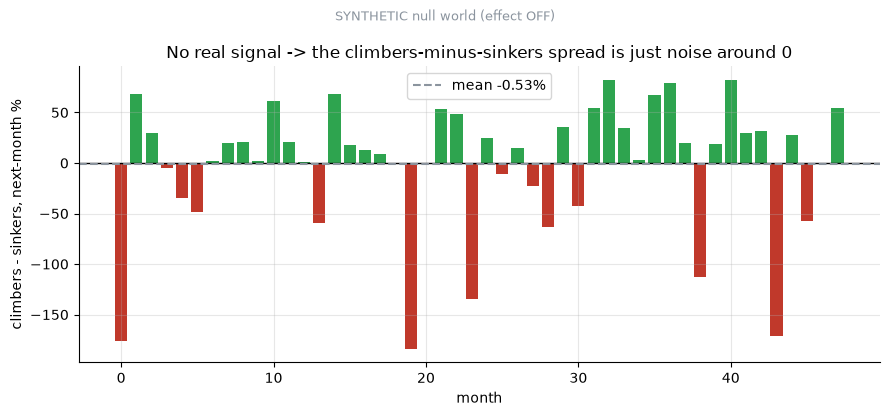

In [2]:
s = st.ic_summary(NULL); ls = st.long_short_summary(NULL)
print(f"honest (no-signal) world: mean IC {s['mean_ic']:+.3f} (t {s['t']:+.2f}), "
      f"long-short {ls['gross']*100:+.2f}%/mo (t {ls['t']:+.2f})")
# show the monthly long-short spread wandering around zero
lss = st.long_short_series(NULL)*100
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.bar(lss.index, lss.values, color=[GREEN if v>0 else RED for v in lss.values], width=.8)
ax.axhline(0, c='k', lw=1); ax.axhline(lss.mean(), c=GREY, ls='--', lw=1.5, label=f'mean {lss.mean():+.2f}%')
ax.set_xlabel('month'); ax.set_ylabel('climbers - sinkers, next-month %')
ax.set_title('No real signal -> the climbers-minus-sinkers spread is just noise around 0')
ax.legend(); fig.suptitle('SYNTHETIC null world (effect OFF)', fontsize=9, color=GREY)
plt.tight_layout(); plt.show()

> The mean is essentially zero (**-0.53%/mo**, *t* -0.06). Good — that's exactly what a *no-signal* world should show. This is our baseline: any real edge would have to stand out from this.

**But does our measuring stick actually work?** Let's turn the effect *on* (a world where app-climb really does predict returns) and check the engine catches it — flat when off, rising when on, averaged over 25 different random worlds so no single lucky draw fools us.

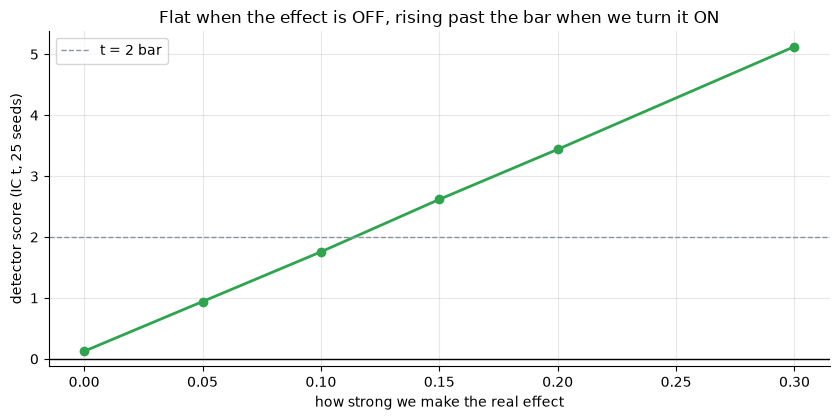

effect 0.00 -> detector score +0.12
effect 0.05 -> detector score +0.94
effect 0.10 -> detector score +1.76
effect 0.15 -> detector score +2.62
effect 0.20 -> detector score +3.44
effect 0.30 -> detector score +5.13


In [3]:
alphas = [0.0, 0.05, 0.1, 0.15, 0.2, 0.3]
ts = [st.synthetic_mean_ic_t(data, rank_alpha=a, n_seeds=25) for a in alphas]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(alphas, ts, 'o-', c=GREEN, lw=2)
ax.axhline(2, ls='--', c=GREY, lw=1, label='t = 2 bar')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('how strong we make the real effect'); ax.set_ylabel('detector score (IC t, 25 seeds)')
ax.set_title('Flat when the effect is OFF, rising past the bar when we turn it ON')
ax.legend(); plt.tight_layout(); plt.show()
for a, t in zip(alphas, ts): print(f'effect {a:.2f} -> detector score {t:+.2f}')

So the engine is honest: **~0 when there's nothing there, past the bar when there is.** That means the flat headline is the *data* talking (no signal to find, because we don't have real ranks), not a broken tool.

## 5 · The verdict

- **Signal — Weak.** The idea is plausible and our detector works, **but there's no free real App Store history to test it on**, so it can never earn 'Real'. And even a genuine effect sinks below the bar once the rank read is realistically noisy (next notebook).
- **Tradability — Mirage.** You'd short small, hard-to-borrow sinking-app names and rebalance monthly; the book bleeds after costs.

## 6 · Could you actually trade it?

No. Even setting aside 'we can't get the data', the trade means **shorting the companies whose apps sank** — often the smallest, most fragile, hardest-to-borrow names — and doing it *every month*. In the honest world the spread is already negative before you pay a cent; add a monthly rebalance and a borrow fee and it only gets worse.

## 7 · Going further 🚪

- **The single-name cousin.** [294 Coinbase-Rank](../../294-coinbase-rank/) tests the *contrarian top* version on one asset.
- **The data wall.** The real test needs a paid, point-in-time, survivorship-clean rank panel joined to tickers — exactly what a retail stack can't reach.

*Have licensed rank history? Fork this, feed a real panel into the same IC engine, and show the climbers-minus-sinkers spread clearing t = 2 after costs.*